<a href="https://colab.research.google.com/github/dhiraj0911/ai-engineering/blob/main/gradient_backpropagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [119]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [120]:
def f(x):
  return 3 * x ** 2 - 4 * x + 5

In [121]:
f(3.0)

20.0

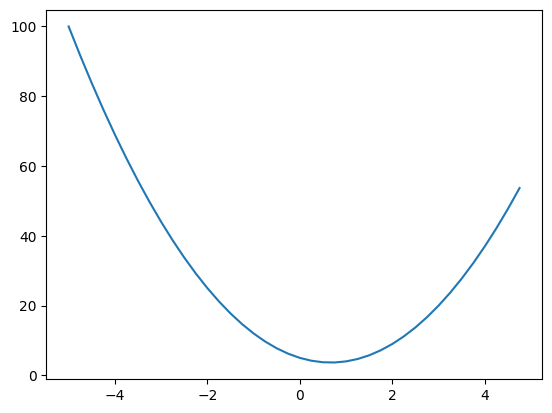

In [122]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [123]:
a = 2.0
b = -3.0
c = 10.0
d = a * b + c
print(d)

4.0


In [124]:
h = 0.0001

a = 2
b = -3
c = 10


d1 = a * b + c
a += h
d2 = a * (b + h) + c

slope = (d2 - d1) / h
print(slope)


-0.9998999999982772


In [125]:
class Value:
  # childer:
  # we were missing connective issue of the expression
  # to this expression graph we need to know and keep pointers
  # of what values produces what other values

  # operations:
  # we don't know what values created this operations
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self._prev = set(_children)
    self._op = _op
    self.label = label
    self.grad = 0.0
    self._backward = lambda: None

  # 3 * a then convert it to a * 3
  def __rmul__(self, other):
    return self * other

  # this provide a way to print nicer looking function in function
  # otherwise there will be some cryptic value
  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    # a will be self and b will be other
    output = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * output.grad
      other.grad += 1.0 * output.grad
    output._backward = _backward

    return output

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    output = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * output.grad
      other.grad += self.data * output.grad
    output._backward = _backward
    return output

  def __truediv__(self, other): # self/other
    return self * other**-1

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    output = Value(self.data**other, (self,), f'**{other}')
    def _backward():
      self.grad += (other * self.data**(other-1)) * output.grad
    output._backward = _backward
    return output

  def __sub__(self, other):
      return self + (-other)

  def exp(self):
    x = self.data
    output = Value(math.exp(x), (self, ), 'exp')

    def _backward():
      self.grad += output.data * output.grad
    output._backward = _backward
    return output

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
    output = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * output.grad
    output._backward = _backward
    return output

  def backward(self):
    # base case
    self.grad = 1.0

    # Doing manually instead we can use topological algo
    topo = []
    visited = set ()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    for node in reversed(topo):
      node._backward()

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
# a + b     # -> internally a.__add__(b)
#d = a * b + c     # (a.__mul__(b)).__add__(c)
e = a * b; e.label='e'
d = e + c; d.label='d'
f = Value(-2.0, label='f')
L = d * f; L.label='L'

L

Value(data=-8.0)

In [126]:
L.grad = 1
d.grad = -2.0
f.grad = 4

Chain Rule
if z depends on y and y depends on x then z is also depends on x

dz/dx = dz/dy * dy/ dx

d = e + c
dd/de = 1.0
dd/dc = 1.0

Want:
dl/dc

We have:
dl/dd and dd/dc

According to chain rule

dl/dc = dl/dd * dd/dc

In [127]:
# here
# dl/dc = dl/dd * dd/dc = -2 * 1 = -2.0

c.grad = -2.0
# similary
e.grad = -2.0

a.grad = 6.0
b.grad = -4.0

In [128]:
# now we have dl/de = -2.0
c = a * b
# dc/da = b
# dc/db = a
# dl/da = dl/de * de/da = -2.0 * -3 = 6
# dl/db = dl/de * de/db = -2.0 * 2 = - 4

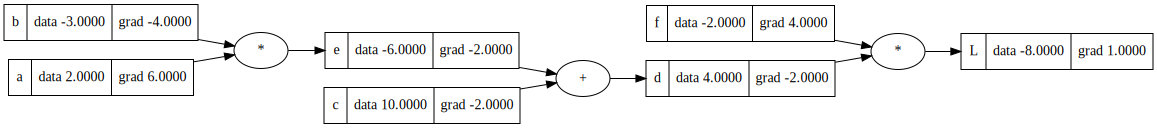

In [129]:
draw_dot(L)

In [130]:
def lol():
  h = 0.00001

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a * b; e.label='e'
  d = e + c; d.label='d'
  f = Value(-2.0, label='f')
  L = d * f; L.label='L'
  L1 = L.data


  a = Value(2.0, label='a')
  # a.data += h
  b = Value(-3.0, label='b')
  b.data += h
  c = Value(10.0, label='c')
  # c.data += h
  e = a * b; e.label='e'
  # e.data += h
  d = e + c; d.label='d'
  #d.data += h
  f = Value(-2.0, label='f')
  L= d * f; L.label='L'
  L2 = L.data

  print((L2 - L1) / h)

lol();

-4.000000000026205


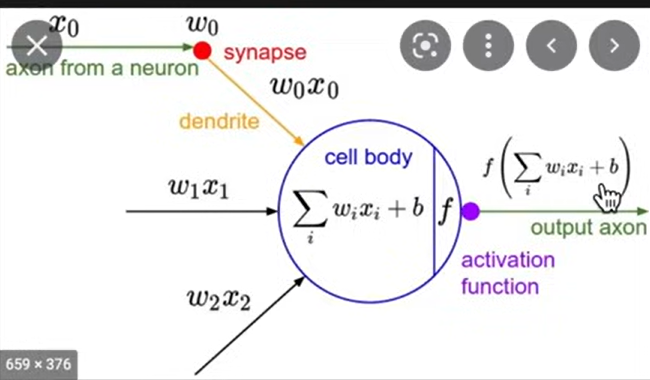

In [131]:
# this is basic neuron network
#inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
#weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
#bias
b = Value(6.87, label='b')
# x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh()



In [132]:
# o.grad = 1.0
# o._backward()
# n._backward()
# b._backward()
# x1w1x2w2._backward()
# x1w1._backward()
# x2w2._backward()
# x1._backward()
# x2._backward()
# w1._backward()
# w2._backward()

# base case
o.grad = 1.0
'''
# Doing manually instead we can use topological algo
topo = []
visited = set ()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)

for node in reversed(topo):
  node._backward()
'''

o.backward()

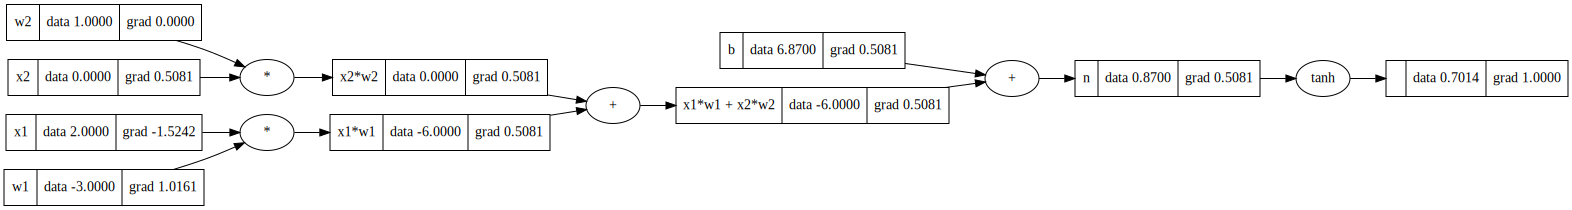

In [133]:
draw_dot(o)

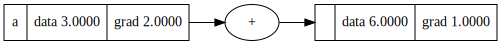

In [134]:
a = Value(3.0, label='a')
b = a + a; label = 'b'
b.backward()
draw_dot(b)

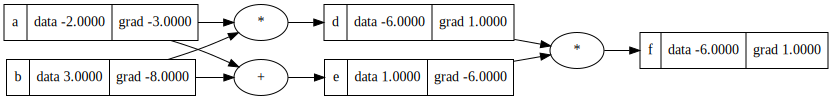

In [135]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
# c = a + b; c.label = 'c'
d = a * b; d.label = 'd'
e = a + b; e.label = 'e'
f = d * e; f.label = 'f'

f.backward()
draw_dot(f)

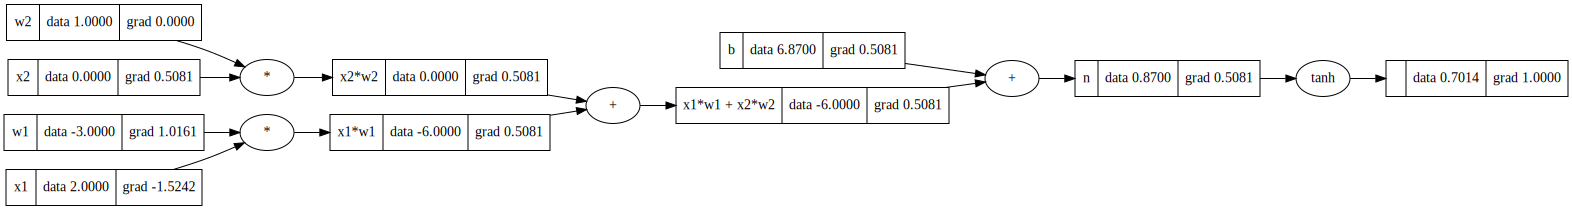

In [137]:
# this is basic neuron network
#inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
#weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
#bias
b = Value(6.87, label='b')
# x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh()
o.backward()
draw_dot(o)

In [152]:
import torch
import random

In [153]:
x1 = torch.Tensor([2.0]).double(); x1.requires_grad=True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad=True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad=True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad=True
b = torch.Tensor([6.87]).double(); b.requires_grad=True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7013740727938153
---
x2 0.508074410012616
w2 0.0
x1 -1.524223230037848
w1 1.016148820025232


In [154]:
o

tensor([0.7014], dtype=torch.float64, grad_fn=<TanhBackward0>)

In [155]:
o.item()

0.7013740727938153

In [156]:
# what we build which is agree with pytorch

In [157]:
# Neural Nets are just a spcific class of mathematical expressions

In [165]:
class Neuron:

  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]

class Layer:

  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

Value(data=-0.9809028752583036)